In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

### The Problem: One Model Isn't Enough

Imagine you're trying to predict house prices. One decision tree makes mistakes. What if you could:

1. Build a tree
2. See where it's wrong
3. Build another tree to fix those errors
4. Repeat!

**That's Boosting!**

#### Boosting Process (Mermaid Diagram)

```mermaid
graph TD
    A[Step 1: Build Model 1<br>Weak Learner] --> B[Step 2: Find Errors<br>Residuals]
    B --> C[Step 3: Build Model 2<br>to Fix Errors]
    C --> D{More Errors?}
    D -->|Yes| E[Step 4: Build Model 3<br>to Fix More Errors]
    D -->|No| F[Step 5: Combine Models<br>Final Prediction]
    E --> D
    F --> G[✅ Strong Ensemble Model]

```    

#### Boosting = Build Models Sequentially to Correct Previous Errors!
Model 1 → Find errors → Model 2 → Fix errors → Model 3 → ...

#### Boosting vs Other Ensemble Methods

| Method | How It Works | Example |
|--------|--------------|---------|
| **Bagging** | Parallel models, average results | Random Forest |
| **Boosting** | Sequential models, correct errors | XGBoost, AdaBoost |
| **Stacking** | Multiple models, meta-learner | StackingClassifier |

Bagging = Parallel = Reduce Variance

Boosting = Sequential = Reduce Bias

Stacking = Combined = Best of Both

#### What Makes XGBoost Special?

**XGBoost** = eXtreme Gradient Boosting

XGBoost takes Gradient Boosting and adds **extreme optimizations**:

| Feature | Why It Helps |
|---------|--------------|
| **Regularization** | Prevents overfitting (L1/L2 penalties) |
| **Pruning** | Removes splits that don't improve |
| **Parallelization** | Uses all CPU cores |
| **Tree Pruning** | Builds tree depth-first, prunes backwards |
| **Handling Missing Values** | Learns best direction for missing values |
| **Cross-Validation** | Built-in CV during training |

#### XGBoost vs Standard Gradient Boosting

| Feature | Standard GB | XGBoost |
|---------|-------------|---------|
| **Regularization** | ❌ No | ✅ Yes (L1/L2) |
| **Pruning** | ❌ No | ✅ Yes |
| **Parallelization** | ❌ No | ✅ Yes |
| **Missing Values** | ❌ Must impute | ✅ Handles automatically |
| **Built-in CV** | ❌ No | ✅ Yes |
| **Speed** | Slow | ✅ Fast |


#### XGBoost Objective Functions

| Task | Default / Recommended Objective |
|------|--------------------------------|
| **Binary Classification** | `'binary:logistic'` (Default) |
| **Multi-class Classification** | `'multi:softmax'` or `'multi:softprob'` |
| **Regression** | `'reg:squarederror'` |

House Size vs Price:
  500 sq ft → $150k
  800 sq ft → $200k
  1000 sq ft → $250k
  1200 sq ft → $300k
  1500 sq ft → $350k
  1800 sq ft → $400k
  2000 sq ft → $450k
  2200 sq ft → $500k


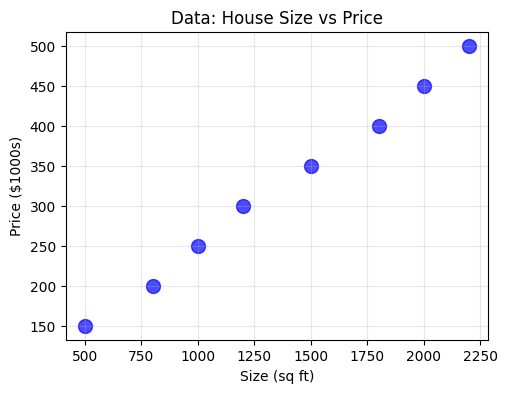

In [3]:
# dataset: Size (sq ft) → Price ($1000s)
X = np.array([500, 800, 1000, 1200, 1500, 1800, 2000, 2200]).reshape(-1, 1)
y = np.array([150, 200, 250, 300, 350, 400, 450, 500])

print("House Size vs Price:")
for i in range(len(X)):
    print(f"  {X[i][0]} sq ft → ${y[i]}k")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.scatter(X, y, s=100, color='blue', alpha=0.7)
plt.xlabel('Size (sq ft)')
plt.ylabel('Price ($1000s)')
plt.title('Data: House Size vs Price')
plt.grid(True, alpha=0.3)

In [10]:
# Step 1: start with a simple prediction
initial_prediction = np.mean(y)
print(f"\nmean = {initial_prediction:.1f} k/$")

# residuals (errors)
residuals = y - initial_prediction
print(f"\nResiduals (errors):")
for i, r in enumerate(residuals):
    print(f"  House {i+1}: True=${y[i]} k/$, Pred=${initial_prediction:.1f} k/$, Error={r:.1f} k/$")


mean = 325.0 k/$

Residuals (errors):
  House 1: True=$150 k/$, Pred=$325.0 k/$, Error=-175.0 k/$
  House 2: True=$200 k/$, Pred=$325.0 k/$, Error=-125.0 k/$
  House 3: True=$250 k/$, Pred=$325.0 k/$, Error=-75.0 k/$
  House 4: True=$300 k/$, Pred=$325.0 k/$, Error=-25.0 k/$
  House 5: True=$350 k/$, Pred=$325.0 k/$, Error=25.0 k/$
  House 6: True=$400 k/$, Pred=$325.0 k/$, Error=75.0 k/$
  House 7: True=$450 k/$, Pred=$325.0 k/$, Error=125.0 k/$
  House 8: True=$500 k/$, Pred=$325.0 k/$, Error=175.0 k/$


In [12]:
# Step 2: build a tree to predict residuals
tree = DecisionTreeRegressor(max_depth=2, random_state=42)
tree.fit(X, residuals)
predicted_residuals = tree.predict(X)

print(f"\nTree trained to predict residuals")
print(f"  Tree structure: depth=2, leaves={tree.get_n_leaves()}")

# Show predictions
print(f"\nTree predictions (residuals):")
for i, pred in enumerate(predicted_residuals):
    print(f"  House {i+1}: Residual={residuals[i]:.1f} k/$ → Tree predicts={pred:.1f} k/$")



Tree trained to predict residuals
  Tree structure: depth=2, leaves=4

Tree predictions (residuals):
  House 1: Residual=-175.0 k/$ → Tree predicts=-150.0 k/$
  House 2: Residual=-125.0 k/$ → Tree predicts=-150.0 k/$
  House 3: Residual=-75.0 k/$ → Tree predicts=-50.0 k/$
  House 4: Residual=-25.0 k/$ → Tree predicts=-50.0 k/$
  House 5: Residual=25.0 k/$ → Tree predicts=50.0 k/$
  House 6: Residual=75.0 k/$ → Tree predicts=50.0 k/$
  House 7: Residual=125.0 k/$ → Tree predicts=150.0 k/$
  House 8: Residual=175.0 k/$ → Tree predicts=150.0 k/$


In [13]:
# Step 3: update predictions
learning_rate = 0.1  # Shrinkage parameter
updated_predictions = initial_prediction + learning_rate * predicted_residuals

print(f"\nUpdate predictions with learning_rate={learning_rate}")
print(f"\nUpdated predictions:")
for i in range(len(X)):
    print(f"  House {i+1}: {updated_predictions[i]:.1f}k (vs true ${y[i]}k)")

# Calculate new residuals
new_residuals = y - updated_predictions
print(f"\nNew residuals (errors after update):")
for i, r in enumerate(new_residuals):
    print(f"  House {i+1}: {r:.1f}k")



Update predictions with learning_rate=0.1

Updated predictions:
  House 1: 310.0k (vs true $150k)
  House 2: 310.0k (vs true $200k)
  House 3: 320.0k (vs true $250k)
  House 4: 320.0k (vs true $300k)
  House 5: 330.0k (vs true $350k)
  House 6: 330.0k (vs true $400k)
  House 7: 340.0k (vs true $450k)
  House 8: 340.0k (vs true $500k)

New residuals (errors after update):
  House 1: -160.0k
  House 2: -110.0k
  House 3: -70.0k
  House 4: -20.0k
  House 5: 20.0k
  House 6: 70.0k
  House 7: 110.0k
  House 8: 160.0k


Round 3: MSE = 7268.01
Round 6: MSE = 4076.19
Round 9: MSE = 2275.80


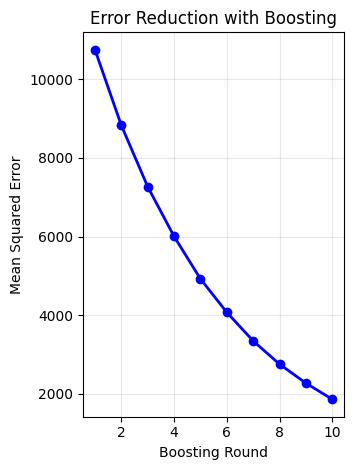


Final MSE: 1865.19 (from 10750.00)
Improvement: 82.6%


In [14]:
# Step 4: repeat (Boosting Iterations)
# Simulate multiple boosting rounds
n_rounds = 10
predictions = np.full_like(y, initial_prediction, dtype=float)
errors = []

for round_num in range(1, n_rounds + 1):
    # Calculate residuals
    residuals = y - predictions
    
    # Train tree on residuals
    tree = DecisionTreeRegressor(max_depth=2, random_state=42)
    tree.fit(X, residuals)
    
    # Update predictions
    predictions += learning_rate * tree.predict(X)
    
    # Calculate error
    mse = np.mean((y - predictions) ** 2)
    errors.append(mse)
    
    if round_num % 3 == 0:
        print(f"Round {round_num}: MSE = {mse:.2f}")

# Visualize improvement
plt.subplot(1, 2, 2)
plt.plot(range(1, n_rounds+1), errors, 'bo-', linewidth=2, markersize=6)
plt.xlabel('Boosting Round')
plt.ylabel('Mean Squared Error')
plt.title('Error Reduction with Boosting')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nFinal MSE: {errors[-1]:.2f} (from {errors[0]:.2f})")
print(f"Improvement: {(errors[0] - errors[-1]) / errors[0] * 100:.1f}%")